In [1]:
import numpy as np
import jax
import jax.numpy as jnp
import equinox as eqx
import diffrax
from jaxtyping import Float

import dismech_jax as djx

from util_multiset_copy import *
from animate import animate

jax.config.update("jax_enable_x64", True)


In [2]:
import equinox as eqx
import jax
import jax.numpy as jnp
from jaxtyping import Float


def inv_softplus(y: jax.Array) -> jax.Array:
    return jnp.log(jnp.expm1(y))


class MLP(eqx.Module):
    layer1: eqx.nn.Linear
    layer2: eqx.nn.Linear

    def __init__(self, in_features: int, hidden_size: int, out_features: int, key: jax.Array):
        key1, key2 = jax.random.split(key)
        self.layer1 = eqx.nn.Linear(in_features, hidden_size, key=key1)
        self.layer2 = eqx.nn.Linear(hidden_size, out_features, key=key2)

        self.layer1 = eqx.tree_at(
            lambda l: l.weight, self.layer1, self.layer1.weight * 1e-2
        )
        self.layer2 = eqx.tree_at(
            lambda l: l.weight, self.layer2, self.layer2.weight * 1e-2
        )

    def __call__(self, x: jax.Array) -> jax.Array:
        x = jnp.ravel(x)
        x = jax.nn.tanh(self.layer1(x))
        x = self.layer2(x)
        return x   # shape (3,)


class Example(TripletModel):
    theta: jax.Array
    mlp: MLP
    rho: float = eqx.field(static=True)
    beta_max: float = eqx.field(static=True)
    corr_scale: float = eqx.field(static=True)
    l_k: float = eqx.field(static=True)
    K: jax.Array = eqx.field(static=True)

    def __init__(
        self,
        der_K: jax.Array,
        key: jax.Array,
        l_k: float = 0.1,
        rho: float = 6,
        beta_max: float = 0.8,
        corr_scale: float = 1e-2,
    ):
        """
        der_K = [k_ss, k_sb, k_bb] (PHYSICAL values)

        l_k rescales stiffness:
            k_ss <- l_k * k_ss
            k_bb <- k_bb / l_k
        """
        der_K = jnp.ravel(der_K)
        if der_K.shape != (3,):
            raise ValueError(f"Expected der_K shape (3,), got {der_K.shape}")
        
        self.K = der_K.copy()  # store physical stiffness for logging

        k_ss0, k_sb0, k_bb0 = der_K
        eps = 1e-6

        # ---- undo scaling to get base stiffness ----
        k_ss_base = k_ss0 / l_k
        k_bb_base = k_bb0 * l_k
        k_sb_base = k_sb0

        if k_ss_base <= 0 or k_bb_base <= 0:
            raise ValueError("Need positive base stiffness.")

        if k_ss_base * k_bb_base - 2.0 * k_sb_base**2 <= 0:
            raise ValueError("Base stiffness must be strictly PD.")

        # ---- convert to bounded parameterization ----
        s0 = k_bb_base
        r0 = k_ss_base / k_bb_base
        beta0 = jnp.sqrt(2.0) * k_sb_base / jnp.sqrt(k_ss_base * k_bb_base)

        log_r0 = jnp.log(r0)
        if jnp.abs(log_r0) >= rho:
            raise ValueError(
                f"Base ratio outside allowed range. "
                f"Try increasing rho or adjusting l_k."
            )

        if jnp.abs(beta0) >= beta_max:
            raise ValueError("Coupling too large for beta_max.")

        raw_scale0 = inv_softplus(s0 - eps)
        raw_ratio0 = jnp.arctanh(jnp.clip(log_r0 / rho, -0.999999, 0.999999))
        raw_beta0 = jnp.arctanh(jnp.clip(beta0 / beta_max, -0.999999, 0.999999))

        self.theta = jnp.array([raw_scale0, raw_ratio0, raw_beta0])
        self.mlp = MLP(in_features=5, hidden_size=10, out_features=3, key=key)
        self.rho = rho
        self.beta_max = beta_max
        self.corr_scale = corr_scale
        self.l_k = l_k

    def _bounded_parameters(self, del_strain):
        eps = 1e-6
        x = jnp.ravel(del_strain)

        dtheta = self.corr_scale * self.mlp(x)
        theta = self.theta + dtheta

        s = jax.nn.softplus(theta[0]) + eps
        log_r = self.rho * jnp.tanh(theta[1])
        r = jnp.exp(log_r)
        beta = self.beta_max * jnp.tanh(theta[2])

        return s, r, beta

    def get_K_entries(self, del_strain):
        # ---- base (well-conditioned) stiffness ----
        s, r, beta = self._bounded_parameters(del_strain)

        k_bb_base = s
        k_ss_base = s * r
        k_sb_base = beta * s * jnp.sqrt(r / 2.0)

        # ---- apply physical scaling ----
        k_ss = self.l_k * k_ss_base
        k_bb = k_bb_base / self.l_k
        k_sb = k_sb_base

        return jnp.array([k_ss, k_sb, k_bb])

    def get_K_matrix(self, del_strain):
        k_ss, k_sb, k_bb = self.get_K_entries(del_strain)
        return jnp.array([
            [k_ss, 0.0,  k_sb],
            [0.0,  k_ss, k_sb],
            [k_sb, k_sb, k_bb],
        ])

    def __call__(self, del_strain):
        del_strain = jnp.ravel(del_strain)

        e0 = del_strain[0]
        e1 = del_strain[1]
        eb = del_strain[3]

        k_ss, k_sb, k_bb = self.get_K_entries(del_strain)

        stretching_energy = 0.5 * k_ss * (e0**2 + e1**2)
        coupling_energy = k_sb * (e0 + e1) * eb
        bending_energy = 0.5 * k_bb * eb**2

        return stretching_energy + coupling_energy + bending_energy

In [3]:
train_datafile = "experiment_data/train.npz"
valid_datafile = "experiment_data/valid.npz"

init_K=jnp.array([0.1, 0.0001, 0.05])
# validate_model(Example, der_K=init_K)

final_model, init_K, train_history, valid_history = train_model(Example, key=jax.random.PRNGKey(42), train_file=train_datafile, valid_file=valid_datafile, n_epochs=500, lr=1e-2, init_K=init_K )

print( "initial K: ", init_K)
print( "learned K: ", final_model.K)

/Users/radha/GitRepos/dismech-jax/examples/slinky/util_multiset_copy.py:265: UserWarning: A JAX array is being set as static! This can result in unexpected behavior and is usually a mistake to do.
  model = cls(der_K=init_K, key=key)


Initial training loss: 1.00664e-04
K: [0.1    0.0001 0.05  ]
grad K: [0.1    0.0001 0.05  ]
loss finite? True
grad finite? True
Step 0    | LR: 1.000e-02  | Train: 1.00664e-04  | Valid: 9.78936e-05  | K: [0.1    0.0001 0.05  ]
Step 10   | LR: 9.991e-03  | Train: 8.55237e-05  | Valid: 8.38450e-05  | K: [0.1    0.0001 0.05  ]
Step 20   | LR: 9.965e-03  | Train: 6.95954e-05  | Valid: 6.85291e-05  | K: [0.1    0.0001 0.05  ]
Step 30   | LR: 9.921e-03  | Train: 5.41377e-05  | Valid: 5.32113e-05  | K: [0.1    0.0001 0.05  ]
Step 40   | LR: 9.859e-03  | Train: 5.65313e-05  | Valid: 4.34877e-05  | K: [0.1    0.0001 0.05  ]
Step 50   | LR: 9.781e-03  | Train: 4.14009e-05  | Valid: 3.53774e-05  | K: [0.1    0.0001 0.05  ]
Step 60   | LR: 9.685e-03  | Train: 2.84978e-05  | Valid: 2.80424e-05  | K: [0.1    0.0001 0.05  ]
Step 70   | LR: 9.573e-03  | Train: 2.20741e-05  | Valid: 2.17900e-05  | K: [0.1    0.0001 0.05  ]
Step 80   | LR: 9.446e-03  | Train: 1.64629e-05  | Valid: 1.61199e-05  | K: [0.1

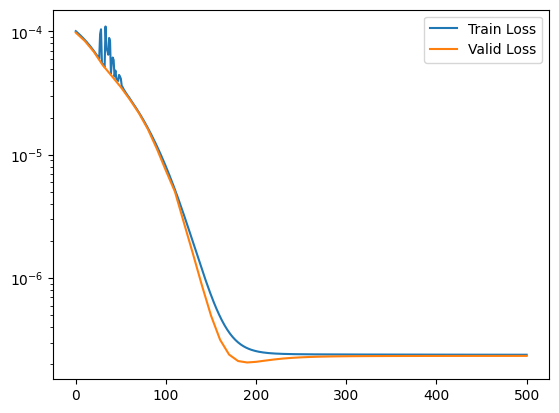

In [4]:
import matplotlib.pyplot as plt
train_np = np.asarray(train_history, dtype=float).reshape(-1)
valid_np = np.asarray(valid_history, dtype=float).reshape(-1)

idx_valid = np.where(valid_np != -1)[0]

plt.plot(np.arange(train_np.size), train_np, label="Train Loss")
plt.plot(idx_valid, valid_np[idx_valid], label="Valid Loss")
plt.yscale("log")
plt.legend()
plt.show()

In [5]:
from util_multiset_copy import TestCase

train = TestCase.from_npz(train_datafile)
valid = TestCase.from_npz(valid_datafile)


print("train.qs finite:", jnp.all(jnp.isfinite(train.qs)))
print("train.xb finite:", jnp.all(jnp.isfinite(train.xb)))
print("train.lambdas finite:", True if train.lambdas is None else jnp.all(jnp.isfinite(train.lambdas)))

print("valid.qs finite:", jnp.all(jnp.isfinite(valid.qs)))
print("valid.xb finite:", jnp.all(jnp.isfinite(valid.xb)))
print("valid.lambdas finite:", True if valid.lambdas is None else jnp.all(jnp.isfinite(valid.lambdas)))


train.qs finite: True
train.xb finite: True
train.lambdas finite: True
valid.qs finite: True
valid.xb finite: True
valid.lambdas finite: True


In [6]:
# base, aux, der = get_base_rod()
# train = TestCase.from_npz(train_datafile)

# model = Example(der_K=jnp.array([0.1, 0.05]), key=jax.random.PRNGKey(42))
# debug_dataset_loss(model, base, aux, train)

In [7]:
def make_bc_from_testcase(dataset, i=None):
    lambdas = dataset.lambdas if dataset.lambdas is not None else jnp.linspace(0.0, 1.0, dataset.qs.shape[1])

    if i is None:
        idx_b = dataset.idx_b
        xb = dataset.xb
    else:
        idx_b = dataset.idx_b if dataset.idx_b.ndim == 1 else dataset.idx_b[i]
        xb = dataset.xb[i]

    print("xb.shape", xb.shape)
    return djx.BatchedDirectBC(
        idx_b=idx_b,
        xb=xb,
        lambdas=lambdas,
    )

In [8]:
print("valid.xb.shape", valid.xb.shape)
lambdas = valid.lambdas if valid.lambdas is not None else jnp.linspace(0.0, 1.0, valid.qs.shape[1])
base, aux, _ = get_base_rod()
bc = make_bc_from_testcase(valid)
rod = base.with_bc(bc)
pred = rod.solve(final_model, lambdas, aux, max_dlambda=5e-3, iters=5, ls_steps=10)
print("pred.shape", pred.shape)
print("valid.qs.shape", valid.qs.shape)
print("train.qs.shape", train.qs.shape)
# animate(pred)

valid.xb.shape (2, 10, 8)
xb.shape (2, 10, 8)
pred.shape (2, 10, 11)
valid.qs.shape (2, 10, 11)
train.qs.shape (2, 10, 11)


In [9]:
# animate(valid.qs)

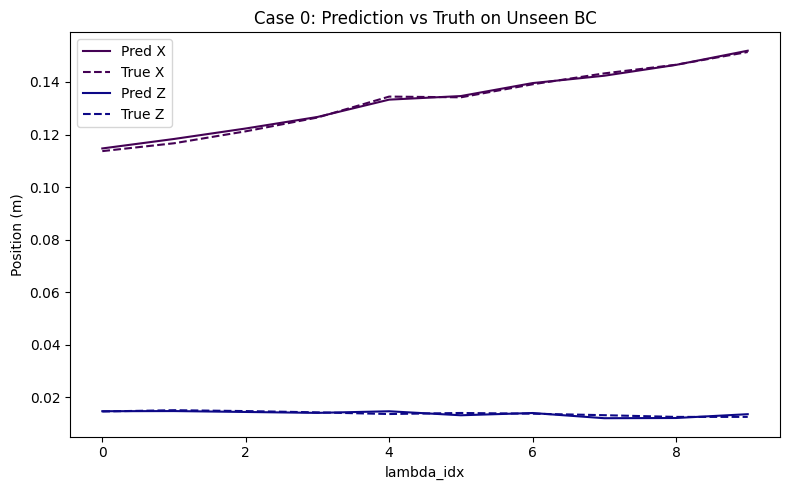

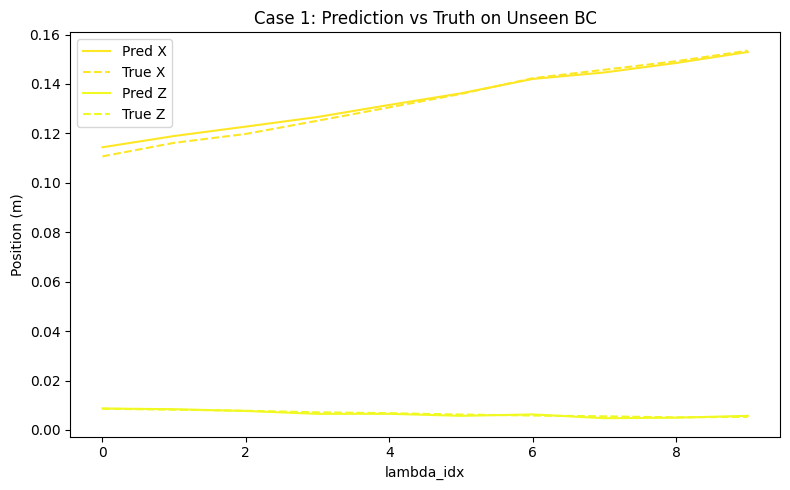

In [10]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import jax.numpy as jnp

n_cases = pred.shape[0]

# one colormap per coordinate
colors_x = cm.viridis(jnp.linspace(0, 1, n_cases))
colors_z = cm.plasma(jnp.linspace(0, 1, n_cases))

for i in range(n_cases):
    cx = colors_x[i]
    cz = colors_z[i]

    fig, ax = plt.subplots(figsize=(8, 5))

    # X coordinate
    ax.plot(pred[i, :, 4], color=cx, linestyle='-', label='Pred X')
    ax.plot(valid.qs[i, :, 4], color=cx, linestyle='--', label='True X')

    # Z coordinate
    ax.plot(pred[i, :, 6], color=cz, linestyle='-', label='Pred Z')
    ax.plot(valid.qs[i, :, 6], color=cz, linestyle='--', label='True Z')

    ax.set_title(f"Case {i}: Prediction vs Truth on Unseen BC")
    ax.set_xlabel("lambda_idx")
    ax.set_ylabel("Position (m)")
    ax.legend()
    fig.tight_layout()
    plt.show()

In [11]:
print("Training BC:")
print("init: ", train.qs[0, 8:11])
print("final: ", train.qs[-1, 8:11])

print("Validation BC:")
print("init: ", valid.qs[0, 8:11])
print("final: ", valid.qs[-1, 8:11])

Training BC:
init:  [[0.         0.         0.         0.         0.11300349 0.
  0.01657482 0.         0.23382102 0.         0.13500646]
 [0.         0.         0.         0.         0.10997066 0.
  0.01648045 0.         0.22677252 0.         0.13321703]]
final:  [[0.         0.         0.         0.         0.11143794 0.
  0.01026583 0.         0.23206285 0.         0.11900306]
 [0.         0.         0.         0.         0.10697546 0.
  0.01032906 0.         0.22445548 0.         0.11741954]]
Validation BC:
init:  [[0.         0.         0.         0.         0.14655865 0.
  0.01259217 0.         0.29649265 0.         0.12744382]
 [0.         0.         0.         0.         0.15141125 0.
  0.01260447 0.         0.30737344 0.         0.13081271]]
final:  [[0.         0.         0.         0.         0.14919935 0.
  0.00509007 0.         0.30000829 0.         0.11267491]
 [0.         0.         0.         0.         0.15346497 0.
  0.00529648 0.         0.30894686 0.         0.11458

In [12]:
print("initial position of the middle node in the training data: ", train.qs[0, 4:7])
print("final position of the middle node in the training data: ", train.qs[-1, 4:7])

initial position of the middle node in the training data:  [[0.         0.         0.         0.         0.13277641 0.
  0.01725533 0.         0.26653386 0.         0.13789818]
 [0.         0.         0.         0.         0.12705972 0.
  0.01727204 0.         0.25443739 0.         0.13331234]
 [0.         0.         0.         0.         0.12212673 0.
  0.01723858 0.         0.24612272 0.         0.13362513]]
final position of the middle node in the training data:  [[0.         0.         0.         0.         0.1312469  0.
  0.01043344 0.         0.26560806 0.         0.12132298]
 [0.         0.         0.         0.         0.12613359 0.
  0.01047439 0.         0.25672117 0.         0.12172881]
 [0.         0.         0.         0.         0.12149112 0.
  0.010437   0.         0.24942622 0.         0.12254084]]


In [13]:
print("initial position of the middle node in the validation data: ", valid.qs[0, 4:7])
print("final position of the middle node in the validation data: ", valid.qs[-1, 4:7])

initial position of the middle node in the validation data:  [[0.         0.         0.         0.         0.13444641 0.
  0.01368943 0.         0.27034087 0.         0.13141174]
 [0.         0.         0.         0.         0.13416888 0.
  0.01408874 0.         0.27294775 0.         0.12834982]
 [0.         0.         0.         0.         0.13912665 0.
  0.01381549 0.         0.28279979 0.         0.13075516]]
final position of the middle node in the validation data:  [[0.         0.         0.         0.         0.13052639 0.
  0.00677359 0.         0.2663429  0.         0.11360569]
 [0.         0.         0.         0.         0.13598007 0.
  0.00624168 0.         0.27560766 0.         0.11266652]
 [0.         0.         0.         0.         0.1423159  0.
  0.00583113 0.         0.28722089 0.         0.11468523]]


In [14]:
print("initial position of the middle node in the prediction: ", pred[0, 4:7])
print("final position of the middle node in the prediction: ", pred[-1, 4:7])

initial position of the middle node in the prediction:  [[ 0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   1.33290521e-01 -7.46847817e-05  1.47400187e-02  0.00000000e+00
   2.70340865e-01  0.00000000e+00  1.31411742e-01]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   1.34650754e-01 -7.33048270e-05  1.32151186e-02  0.00000000e+00
   2.72947753e-01  0.00000000e+00  1.28349824e-01]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   1.39582877e-01 -6.65614290e-05  1.40771293e-02  0.00000000e+00
   2.82799791e-01  0.00000000e+00  1.30755157e-01]]
final position of the middle node in the prediction:  [[ 0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   1.31510495e-01 -3.01196336e-04  6.52802268e-03  0.00000000e+00
   2.66342897e-01  0.00000000e+00  1.13605693e-01]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   1.36211997e-01 -2.71229379e-04  5.71262932e-03  0.00000000e+00
   2.75607658e-01  0.0000